# Requirement Setup

In [1]:
!pip install pandas numpy scikit-learn tensorflow matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"\n{'='*60}")
print("DEVICE AVAILABILITY CHECK")
print('='*60)

# Check for GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")
if gpus:
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu}")

# Check for TPU
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print(f"\nTPU detected: {tpu.cluster_spec().as_dict()}")
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print(f"TPU initialized successfully!")
    print(f"Number of TPU cores: {strategy.num_replicas_in_sync}")
    DEVICE_TYPE = 'TPU'
except (ValueError, AttributeError):
    print("\nTPU not detected")
    if gpus:
        strategy = tf.distribute.MirroredStrategy()
        print("Using GPU strategy")
        DEVICE_TYPE = 'GPU'
    else:
        strategy = tf.distribute.get_strategy()
        print("Using CPU strategy")
        DEVICE_TYPE = 'CPU'

print(f"\n{'='*60}")
print(f"TRAINING DEVICE: {DEVICE_TYPE}")
print(f"Strategy: {strategy.__class__.__name__}")
print('='*60)

TensorFlow version: 2.20.0

DEVICE AVAILABILITY CHECK
GPUs available: 0

TPU not detected
Using CPU strategy

TRAINING DEVICE: CPU
Strategy: _DefaultDistributionStrategy


# Data Loading

In [3]:
import pandas as pd

# Load the Kubernetes telemetry dataset
df = pd.read_csv('../data/data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nServices in dataset: {df['service_id'].unique()}")
print(f"\nColumn names:")
print(df.columns.tolist())
df.head()

Dataset shape: (20000, 22)
Date range: 2025-11-01 00:00:00 to 2025-11-14 21:19:00

Services in dataset: ['Order']

Column names:
['timestamp', 'service_id', 'current_pod_count', 'request_rate_rps', 'latency_p95_ms', 'error_rate_percent', 'queue_length', 'pod_cpu_usage_percent_avg', 'pod_cpu_usage_percent_p95', 'pod_memory_usage_mb_avg', 'pod_memory_usage_mb_p95', 'mesh_inbound_rps', 'mesh_inbound_latency_p95', 'mesh_inbound_error_rate', 'degree_centrality', 'eigenvector_centrality', 'betweenness_centrality', 'closeness_centrality', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']


,timestamp,service_id,current_pod_count,request_rate_rps,latency_p95_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,pod_memory_usage_mb_avg,...,mesh_inbound_latency_p95,mesh_inbound_error_rate,degree_centrality,eigenvector_centrality,betweenness_centrality,closeness_centrality,hour_sin,hour_cos,day_sin,day_cos
0,2025-11-01 00:00:00,Order,3,173.47,52.33,0.059,1.34,58.16,82.97,810.4,...,46.33,0.046,0.90,0.93,0.63,0.66,0.0,1.0,-0.975,-0.223
1,2025-11-01 00:01:00,Order,3,170.29,78.22,0.031,1.71,50.66,75.24,946.7,...,63.08,0.022,0.91,0.98,0.72,0.63,0.0,1.0,-0.975,-0.223
2,2025-11-01 00:02:00,Order,3,175.94,62.65,0.035,1.08,52.94,76.57,957.2,...,49.66,0.025,0.82,0.96,0.63,0.70,0.0,1.0,-0.975,-0.223
3,2025-11-01 00:03:00,Order,5,203.86,56.26,0.055,1.80,51.36,75.57,881.2,...,47.59,0.045,0.93,0.98,0.78,0.78,0.0,1.0,-0.975,-0.223
4,2025-11-01 00:04:00,Order,4,213.89,51.96,0.049,0.58,56.22,80.66,993.0,...,43.25,0.044,0.88,0.93,0.74,0.72,0.0,1.0,-0.975,-0.223


In [4]:
# Filter for a single service (Order service for demonstration)
SERVICE_NAME = 'Order'
df_service = df[df['service_id'] == SERVICE_NAME].copy()
df_service = df_service.sort_values('timestamp').reset_index(drop=True)

print(f"\n{SERVICE_NAME} service data shape: {df_service.shape}")
print(f"Time range: {df_service['timestamp'].min()} to {df_service['timestamp'].max()}")
print(f"Number of records: {len(df_service)}")

df_service.head(10)


Order service data shape: (20000, 22)
Time range: 2025-11-01 00:00:00 to 2025-11-14 21:19:00
Number of records: 20000


,timestamp,service_id,current_pod_count,request_rate_rps,latency_p95_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,pod_memory_usage_mb_avg,...,mesh_inbound_latency_p95,mesh_inbound_error_rate,degree_centrality,eigenvector_centrality,betweenness_centrality,closeness_centrality,hour_sin,hour_cos,day_sin,day_cos
0,2025-11-01 00:00:00,Order,3,173.47,52.33,0.059,1.34,58.16,82.97,810.4,...,46.33,0.046,0.90,0.93,0.63,0.66,0.0,1.0,-0.975,-0.223
1,2025-11-01 00:01:00,Order,3,170.29,78.22,0.031,1.71,50.66,75.24,946.7,...,63.08,0.022,0.91,0.98,0.72,0.63,0.0,1.0,-0.975,-0.223
2,2025-11-01 00:02:00,Order,3,175.94,62.65,0.035,1.08,52.94,76.57,957.2,...,49.66,0.025,0.82,0.96,0.63,0.70,0.0,1.0,-0.975,-0.223
3,2025-11-01 00:03:00,Order,5,203.86,56.26,0.055,1.80,51.36,75.57,881.2,...,47.59,0.045,0.93,0.98,0.78,0.78,0.0,1.0,-0.975,-0.223
4,2025-11-01 00:04:00,Order,4,213.89,51.96,0.049,0.58,56.22,80.66,993.0,...,43.25,0.044,0.88,0.93,0.74,0.72,0.0,1.0,-0.975,-0.223
5,2025-11-01 00:05:00,Order,3,136.68,68.90,0.048,0.85,52.14,68.88,922.8,...,53.27,0.037,0.83,0.91,0.73,0.67,0.0,1.0,-0.975,-0.223
6,2025-11-01 00:06:00,Order,4,200.67,72.15,0.047,0.88,52.08,71.70,916.0,...,64.57,0.035,0.92,0.96,0.69,0.74,0.0,1.0,-0.975,-0.223
7,2025-11-01 00:07:00,Order,3,196.02,71.67,0.034,1.98,51.75,72.39,958.1,...,61.28,0.024,0.89,0.95,0.65,0.78,0.0,1.0,-0.975,-0.223
8,2025-11-01 00:08:00,Order,3,146.67,68.45,0.037,0.86,55.37,70.62,842.6,...,54.12,0.028,0.83,0.99,0.71,0.79,0.0,1.0,-0.975,-0.223
9,2025-11-01 00:09:00,Order,3,109.05,60.51,0.033,1.57,63.61,85.26,855.6,...,47.88,0.029,0.88,0.97,0.65,0.71,0.0,1.0,-0.975,-0.223


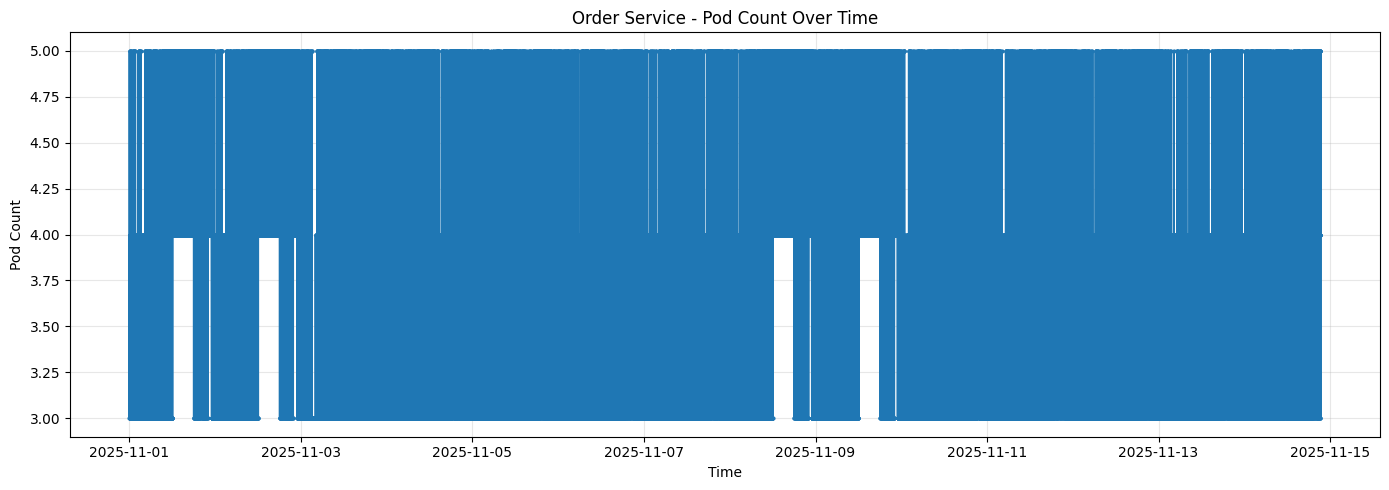


Pod count statistics:
count    20000.000000
mean         3.598900
std          0.798029
min          3.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: current_pod_count, dtype: float64


In [5]:
import matplotlib.pyplot as plt

# Visualize pod count distribution
plt.figure(figsize=(14, 5))
plt.plot(df_service['timestamp'], df_service['current_pod_count'], marker='o', markersize=2)
plt.title(f'{SERVICE_NAME} Service - Pod Count Over Time')
plt.xlabel('Time')
plt.ylabel('Pod Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPod count statistics:")
print(df_service['current_pod_count'].describe())

# Data Preprocessing

1. Create target variable: `next_pod_count` (shifted by 1 timestep)
2. Select multivariate features
3. Handle missing values
4. Normalize features using StandardScaler
5. Split into train/validation/test sets

In [6]:
# Create target variable: next_pod_count (5 minutes ahead)
PREDICTION_HORIZON = 5  # Predict 5 minutes into the future
df_service['next_pod_count'] = df_service['current_pod_count'].shift(-PREDICTION_HORIZON)

# Drop the last N rows (no future pod count available)
df_service = df_service[:-PREDICTION_HORIZON].copy()

print(f"Prediction horizon: {PREDICTION_HORIZON} minutes")
print(f"Dataset shape after creating target: {df_service.shape}")
df_service[['timestamp', 'current_pod_count', 'next_pod_count']].head(10)

Prediction horizon: 5 minutes
Dataset shape after creating target: (19995, 23)


,timestamp,current_pod_count,next_pod_count
0,2025-11-01 00:00:00,3,3.0
1,2025-11-01 00:01:00,3,4.0
2,2025-11-01 00:02:00,3,3.0
3,2025-11-01 00:03:00,5,3.0
4,2025-11-01 00:04:00,4,3.0
5,2025-11-01 00:05:00,3,3.0
6,2025-11-01 00:06:00,4,3.0
7,2025-11-01 00:07:00,3,3.0
8,2025-11-01 00:08:00,3,3.0
9,2025-11-01 00:09:00,3,3.0


In [7]:
# Define feature columns (all numeric columns except timestamp, service_id, and target)
feature_cols = [
    'current_pod_count',
    'request_rate_rps',
    'latency_p95_ms',
    'error_rate_percent',
    'queue_length',
    'pod_cpu_usage_percent_avg',
    'pod_cpu_usage_percent_p95',
    'pod_memory_usage_mb_avg',
    'pod_memory_usage_mb_p95',
    'mesh_inbound_rps',
    'mesh_inbound_latency_p95',
    'mesh_inbound_error_rate',
    'degree_centrality',
    'eigenvector_centrality',
    'betweenness_centrality',
    'closeness_centrality',
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos'
]

target_col = 'next_pod_count'

print(f"Number of input features: {len(feature_cols)}")
print(f"\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

Number of input features: 20

Feature columns:
  1. current_pod_count
  2. request_rate_rps
  3. latency_p95_ms
  4. error_rate_percent
  5. queue_length
  6. pod_cpu_usage_percent_avg
  7. pod_cpu_usage_percent_p95
  8. pod_memory_usage_mb_avg
  9. pod_memory_usage_mb_p95
  10. mesh_inbound_rps
  11. mesh_inbound_latency_p95
  12. mesh_inbound_error_rate
  13. degree_centrality
  14. eigenvector_centrality
  15. betweenness_centrality
  16. closeness_centrality
  17. hour_sin
  18. hour_cos
  19. day_sin
  20. day_cos


In [8]:
# Check for missing values
print("Missing values:")
print(df_service[feature_cols + [target_col]].isnull().sum())

# Fill any missing values with forward fill
df_service[feature_cols] = df_service[feature_cols].fillna(method='ffill').fillna(method='bfill')
df_service[target_col] = df_service[target_col].fillna(method='ffill').fillna(method='bfill')

print(f"\nDataset ready for modeling: {df_service.shape}")

Missing values:
current_pod_count            0
request_rate_rps             0
latency_p95_ms               0
error_rate_percent           0
queue_length                 0
pod_cpu_usage_percent_avg    0
pod_cpu_usage_percent_p95    0
pod_memory_usage_mb_avg      0
pod_memory_usage_mb_p95      0
mesh_inbound_rps             0
mesh_inbound_latency_p95     0
mesh_inbound_error_rate      0
degree_centrality            0
eigenvector_centrality       0
betweenness_centrality       0
closeness_centrality         0
hour_sin                     0
hour_cos                     0
day_sin                      0
day_cos                      0
next_pod_count               0
dtype: int64

Dataset ready for modeling: (19995, 23)


In [9]:
# Split data: 70% train, 15% validation, 15% test
train_size = int(0.70 * len(df_service))
val_size = int(0.15 * len(df_service))

train_df = df_service[:train_size].copy()
val_df = df_service[train_size:train_size + val_size].copy()
test_df = df_service[train_size + val_size:].copy()

print(f"Train set: {len(train_df)} samples ({len(train_df)/len(df_service)*100:.1f}%)")
print(f"Validation set: {len(val_df)} samples ({len(val_df)/len(df_service)*100:.1f}%)")
print(f"Test set: {len(test_df)} samples ({len(test_df)/len(df_service)*100:.1f}%)")
print(f"Total: {len(df_service)} samples")

Train set: 13996 samples (70.0%)
Validation set: 2999 samples (15.0%)
Test set: 3000 samples (15.0%)
Total: 19995 samples


In [10]:
from sklearn.preprocessing import StandardScaler

# Normalize features using StandardScaler (fit on train set only)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit on training data
scaler_X.fit(train_df[feature_cols])
scaler_y.fit(train_df[[target_col]])

# Transform all sets
train_X_scaled = scaler_X.transform(train_df[feature_cols])
train_y_scaled = scaler_y.transform(train_df[[target_col]])

val_X_scaled = scaler_X.transform(val_df[feature_cols])
val_y_scaled = scaler_y.transform(val_df[[target_col]])

test_X_scaled = scaler_X.transform(test_df[feature_cols])
test_y_scaled = scaler_y.transform(test_df[[target_col]])

print("Data normalized successfully")
print(f"Train X shape: {train_X_scaled.shape}")
print(f"Train y shape: {train_y_scaled.shape}")

Data normalized successfully
Train X shape: (13996, 20)
Train y shape: (13996, 1)


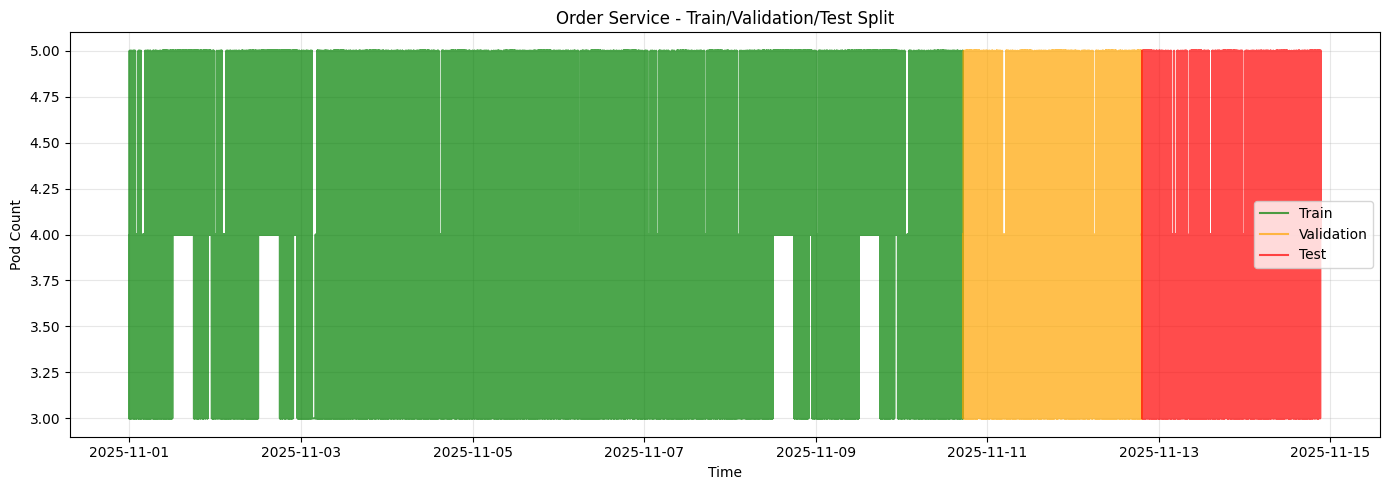

In [11]:
# Visualize train/val/test split
plt.figure(figsize=(14, 5))
plt.plot(train_df['timestamp'], train_df['current_pod_count'], label='Train', color='green', alpha=0.7)
plt.plot(val_df['timestamp'], val_df['current_pod_count'], label='Validation', color='orange', alpha=0.7)
plt.plot(test_df['timestamp'], test_df['current_pod_count'], label='Test', color='red', alpha=0.7)
plt.title(f'{SERVICE_NAME} Service - Train/Validation/Test Split')
plt.xlabel('Time')
plt.ylabel('Pod Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sequence Generation

Create sliding windows of historical data for the Informer model.

**Input:** Sequence of past timesteps (lookback window)

**Output:** Next pod count (single value)

In [12]:
def create_sequences(X, y, lookback=10):
    """
    Create sequences for time-series prediction.
    
    Args:
        X: Feature array (samples, features)
        y: Target array (samples, 1)
        lookback: Number of past timesteps to use
    
    Returns:
        X_seq: Sequences (samples, lookback, features)
        y_seq: Targets (samples, 1)
    """
    X_seq, y_seq = [], []
    
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i + lookback])
        y_seq.append(y[i + lookback])
    
    return np.array(X_seq), np.array(y_seq)

# Set lookback window (reduced for faster training on CPU)
LOOKBACK = 10  # Use past 10 timesteps (10 minutes of data)

print(f"Lookback window: {LOOKBACK} timesteps")
print("Note: Reduced from 20 to 10 for faster CPU training")

Lookback window: 10 timesteps
Note: Reduced from 20 to 10 for faster CPU training


In [13]:
import numpy as np

# Create sequences for train, validation, and test sets
X_train_seq, y_train_seq = create_sequences(train_X_scaled, train_y_scaled, lookback=LOOKBACK)
X_val_seq, y_val_seq = create_sequences(val_X_scaled, val_y_scaled, lookback=LOOKBACK)
X_test_seq, y_test_seq = create_sequences(test_X_scaled, test_y_scaled, lookback=LOOKBACK)

print(f"Training sequences: {X_train_seq.shape}")
print(f"  - Shape interpretation: ({X_train_seq.shape[0]} samples, {X_train_seq.shape[1]} timesteps, {X_train_seq.shape[2]} features)")
print(f"Training targets: {y_train_seq.shape}")
print()
print(f"Validation sequences: {X_val_seq.shape}")
print(f"Validation targets: {y_val_seq.shape}")
print()
print(f"Test sequences: {X_test_seq.shape}")
print(f"Test targets: {y_test_seq.shape}")

Training sequences: (13986, 10, 20)
  - Shape interpretation: (13986 samples, 10 timesteps, 20 features)
Training targets: (13986, 1)

Validation sequences: (2989, 10, 20)
Validation targets: (2989, 1)

Test sequences: (2990, 10, 20)
Test targets: (2990, 1)


# Informer Model Definition

Implement a Transformer-based Informer model with:
- Multi-head attention mechanism
- Positional encoding
- Feed-forward networks
- Layer normalization
- Dropout for regularization

In [14]:
import numpy as np
import tensorflow as tf

def positional_encoding(length, depth):
    """
    Generate positional encoding for transformer.
    
    Args:
        length: Sequence length
        depth: Embedding dimension
    
    Returns:
        Positional encoding array (length, depth)
    """
    depth = int(depth / 2)
    positions = np.arange(length)[:, np.newaxis]
    depths = np.arange(depth)[np.newaxis, :] / depth
    angle_rates = 1 / (10000 ** depths)
    angle_rads = positions * angle_rates
    
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    
    return tf.cast(pos_encoding, dtype=tf.float32)

class PositionalEmbedding(tf.keras.layers.Layer):
    """Positional embedding layer."""
    
    def __init__(self, sequence_length, d_model):
        super().__init__()
        self.d_model = d_model
        self.pos_encoding = positional_encoding(length=sequence_length, depth=d_model)
    
    def call(self, x):
        length = tf.shape(x)[1]
        x = x + self.pos_encoding[tf.newaxis, :length, :]
        return x

In [15]:
class TransformerBlock(tf.keras.layers.Layer):
    """Transformer encoder block with multi-head attention."""
    
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)
    
    def call(self, x, training=False):
        # Multi-head attention (pass training flag)
        attn_output = self.att(x, x, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        
        # Feed-forward network
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        
        return out2

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_informer_model(seq_length, n_features, d_model=64, num_heads=4, num_layers=2, dff=128, dropout_rate=0.1):
    """
    Build Informer model for time-series forecasting.
    
    Args:
        seq_length: Input sequence length (lookback)
        n_features: Number of input features
        d_model: Dimension of the model
        num_heads: Number of attention heads
        num_layers: Number of transformer blocks
        dff: Dimension of feed-forward network
        dropout_rate: Dropout rate
    
    Returns:
        Keras model
    """
    inputs = layers.Input(shape=(seq_length, n_features))
    
    # Project input features to d_model dimension
    x = layers.Dense(d_model)(inputs)
    
    # Add positional encoding
    x = PositionalEmbedding(seq_length, d_model)(x)
    
    # Stack transformer blocks
    for _ in range(num_layers):
        x = TransformerBlock(d_model, num_heads, dff, dropout_rate)(x, training=True)
    
    # Global average pooling
    x = layers.GlobalAveragePooling1D()(x)
    
    # Output layer (predicting next pod count)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1)(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [17]:
# Build the Informer model with appropriate strategy for TPU/GPU/CPU
# Ensure 'strategy' exists (in case the device-check cell wasn't run)
# Ensure 'layers' is available in this cell's scope (some notebook executions may skip prior import cells)
from tensorflow.keras import layers

if 'strategy' not in globals() or strategy is None:
    try:
        # Try to infer available devices and create a reasonable default strategy
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            strategy = tf.distribute.MirroredStrategy()
            DEVICE_TYPE = 'GPU'
        else:
            strategy = tf.distribute.get_strategy()
            DEVICE_TYPE = 'CPU'
        print(f"Created fallback strategy: {strategy.__class__.__name__}")
    except Exception as e:
        # Last-resort fallback
        strategy = tf.distribute.get_strategy()
        DEVICE_TYPE = 'CPU'
        print(f"Fallback to default strategy due to error: {e}")

with strategy.scope():
    model = build_informer_model(
        seq_length=LOOKBACK,
        n_features=len(feature_cols),
        d_model=32,        # Reduced from 64
        num_heads=2,       # Reduced from 4
        num_layers=1,      # Reduced from 2
        dff=64,            # Reduced from 128
        dropout_rate=0.1
    )
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

print(f"Model built with {DEVICE_TYPE} strategy")
print(f"Configuration:")
print("  - d_model: 32")
print("  - num_heads: 2")
print("  - num_layers: 1")
print("  - dff: 64")
print()

# Display model architecture
model.summary()


Model built with CPU strategy
Configuration:
  - d_model: 32
  - num_heads: 2
  - num_layers: 1
  - dff: 64



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10, 32)         │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 10, 32)         │             0 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 10, 32)         │        12,736 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,497 (56.63 KB)

 Trainable params: 14,497 (56.63 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

Train the Informer model with:
- Early stopping to prevent overfitting
- Learning rate reduction on plateau
- Model checkpoint to save best weights

In [18]:
# Define callbacks (adjusted patience for faster training)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,       # Reduced from 20
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,        # Reduced from 10
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    'models/informer_k8s_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("Callbacks configured (optimized for faster training):")

Callbacks configured (optimized for faster training):


In [19]:
# Train the model (reduced epochs for faster CPU training)
EPOCHS = 50         # Reduced from 100
BATCH_SIZE = 32

print(f"Starting training...")
print(f"Epochs: {EPOCHS} (reduced from 100 for CPU)")
print(f"Batch size: {BATCH_SIZE}")
print()

start_time = time.time()

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

Starting training...
Epochs: 50 (reduced from 100 for CPU)
Batch size: 32

Epoch 1/50
430/438 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8363 - mae: 0.7032
Epoch 1: val_loss improved from None to 0.68561, saving model to models/informer_k8s_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.7304 - mae: 0.6610 - val_loss: 0.6856 - val_mae: 0.6190 - learning_rate: 0.0010
Epoch 2/50
430/438 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6766 - mae: 0.6415
Epoch 2: val_loss did not improve from 0.68561
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.6825 - mae: 0.6438 - val_loss: 0.7260 - val_mae: 0.6082 - learning_rate: 0.0010
Epoch 3/50
430/438 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6817 - mae: 0.6377
Epoch 3: val_loss improved from 0.68561 to 0.68328, saving model to models/informer_k8s_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6784 - mae: 0.6390 - val_loss: 0.6833 - val_mae: 0.6415 - learning_rate: 0.0010
Epoch 4/50
432/438 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

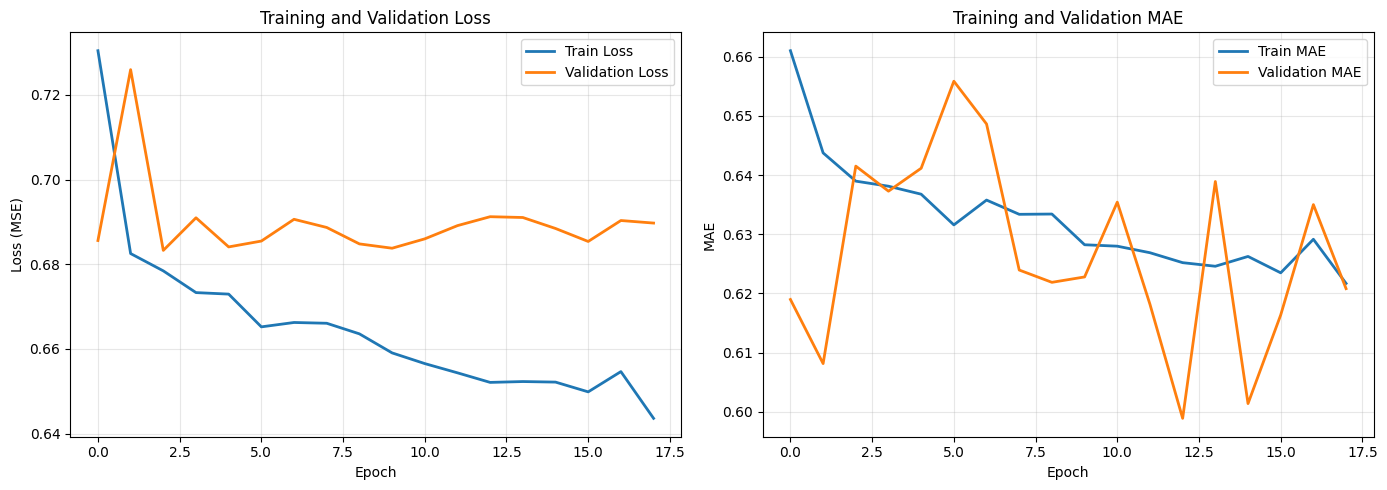


Final training loss: 0.643622
Final validation loss: 0.689735
Best validation loss: 0.683282


In [20]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Training and Validation MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal training loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")
print(f"Best validation loss: {min(history.history['val_loss']):.6f}")

# Model Evaluation

Evaluate the model on test set with metrics:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R² Score

In [21]:
# Make predictions on test set
start_time = time.time()
y_pred_scaled = model.predict(X_test_seq)
prediction_time = time.time() - start_time

# Inverse transform predictions and actual values
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test = scaler_y.inverse_transform(y_test_seq)

print(f"Predictions generated in {prediction_time:.4f} seconds")
print(f"Average prediction time per sample: {prediction_time/len(X_test_seq)*1000:.2f} ms")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Predictions generated in 0.8002 seconds
Average prediction time per sample: 0.27 ms


In [22]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# MAPE (avoiding division by zero)
mape = np.mean(np.abs((y_test - y_pred) / np.where(y_test != 0, y_test, 1))) * 100

# R² Score
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

print("="*50)
print("INFORMER MODEL - TEST SET METRICS")
print("="*50)
print(f"Mean Absolute Error (MAE):       {mae:.4f} pods")
print(f"Root Mean Squared Error (RMSE):  {rmse:.4f} pods")
print(f"Mean Absolute Percentage Error:  {mape:.2f}%")
print(f"R² Score:                        {r2:.4f}")
print("="*50)
print(f"\nTest samples: {len(y_test)}")
print(f"Average inference time: {prediction_time/len(X_test_seq)*1000:.2f} ms/sample")

INFORMER MODEL - TEST SET METRICS
Mean Absolute Error (MAE):       0.5268 pods
Root Mean Squared Error (RMSE):  0.6766 pods
Mean Absolute Percentage Error:  14.18%
R² Score:                        0.2576

Test samples: 2990
Average inference time: 0.27 ms/sample


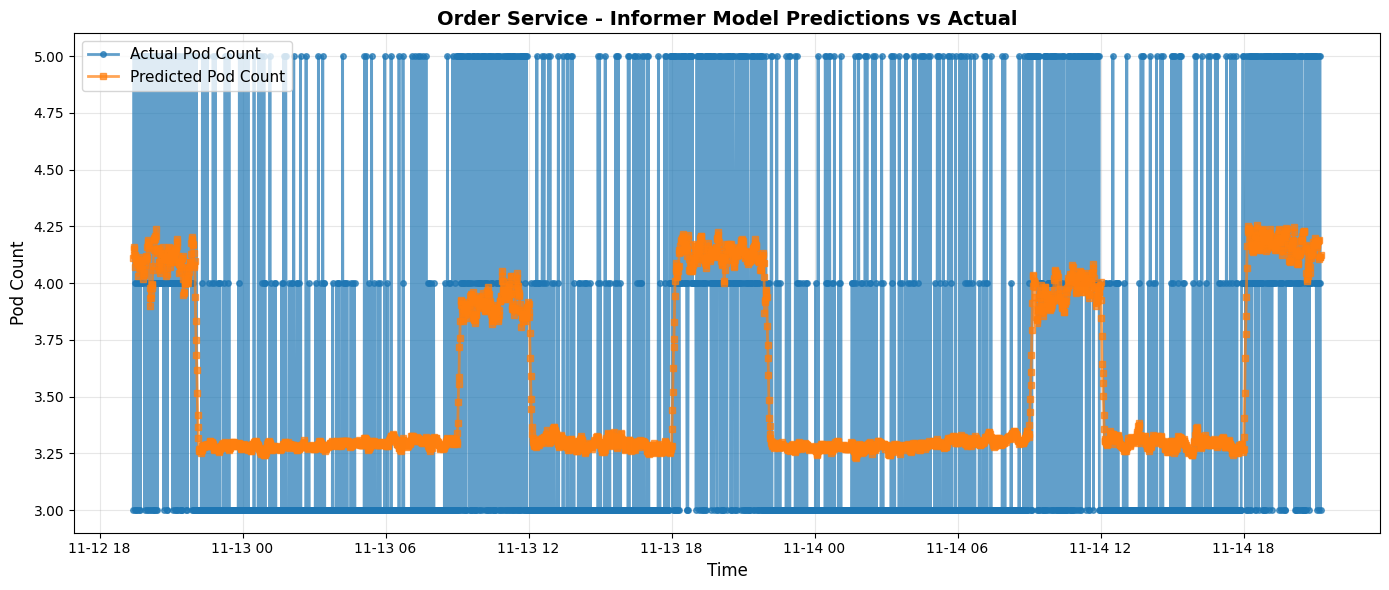

In [23]:
# Visualize predictions vs actual values
plt.figure(figsize=(14, 6))

# Get corresponding timestamps for test set (accounting for lookback)
test_timestamps = test_df['timestamp'].iloc[LOOKBACK:].values

plt.plot(test_timestamps, y_test, label='Actual Pod Count', marker='o', markersize=4, linewidth=2, alpha=0.7)
plt.plot(test_timestamps, y_pred, label='Predicted Pod Count', marker='s', markersize=4, linewidth=2, alpha=0.7)

plt.title(f'{SERVICE_NAME} Service - Informer Model Predictions vs Actual', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Pod Count', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

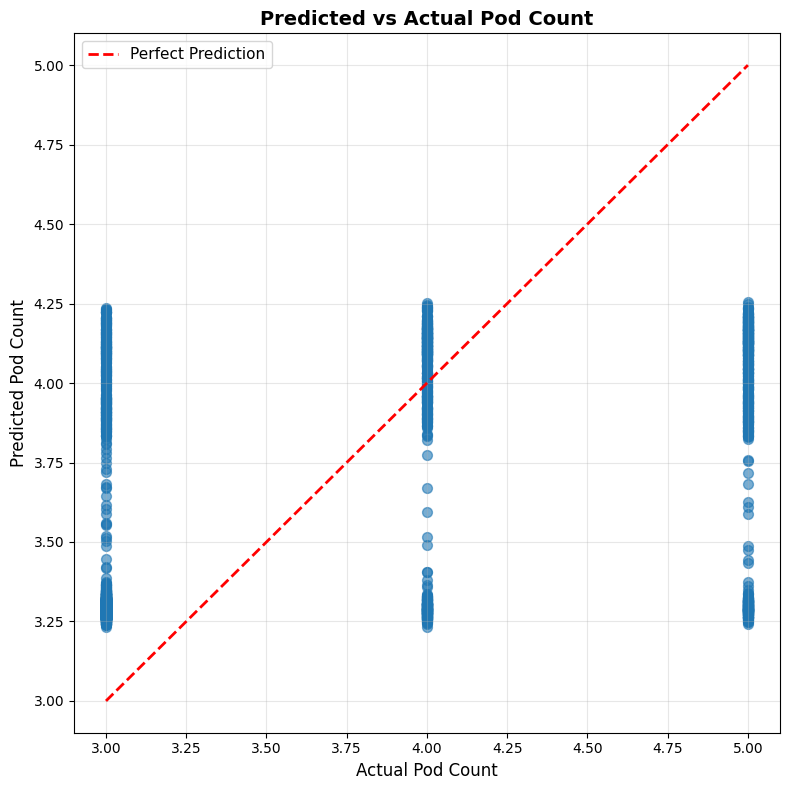

Correlation coefficient: 0.5103


In [24]:
# Scatter plot: Predicted vs Actual
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6, s=50)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Pod Count', fontsize=12)
plt.ylabel('Predicted Pod Count', fontsize=12)
plt.title('Predicted vs Actual Pod Count', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation coefficient: {np.corrcoef(y_test.flatten(), y_pred.flatten())[0, 1]:.4f}")

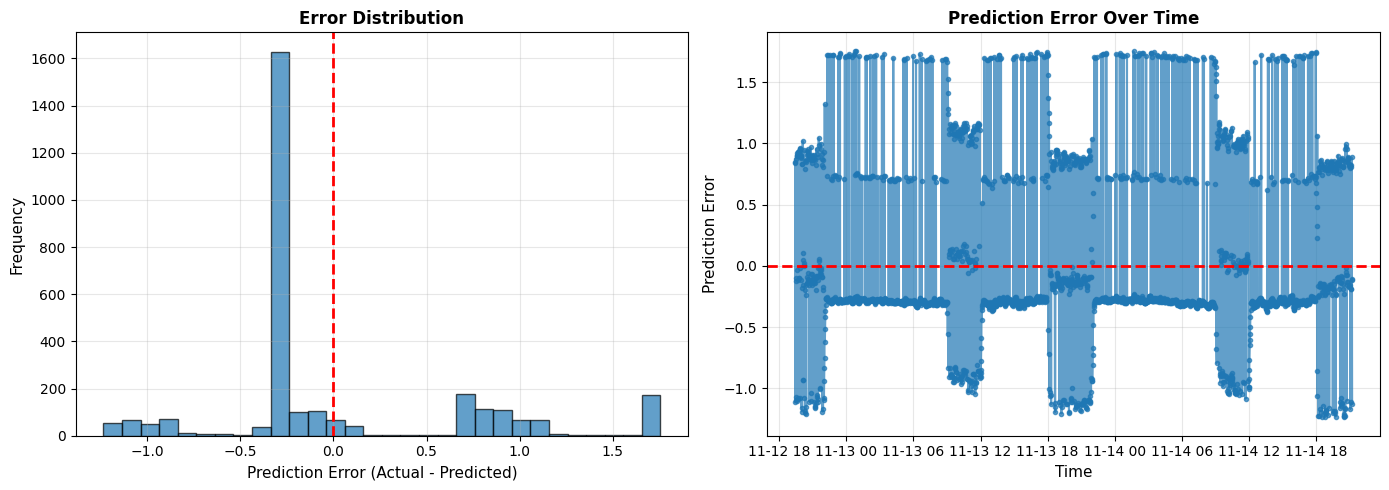

Error statistics:
  Mean error: 0.0024
  Std error: 0.6766
  Min error: -1.2368
  Max error: 1.7573


In [25]:
# Prediction error distribution
errors = y_test.flatten() - y_pred.flatten()

plt.figure(figsize=(14, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Error Distribution', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Time series of errors
plt.subplot(1, 2, 2)
plt.plot(test_timestamps, errors, marker='o', markersize=3, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Time', fontsize=11)
plt.ylabel('Prediction Error', fontsize=11)
plt.title('Prediction Error Over Time', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Error statistics:")
print(f"  Mean error: {errors.mean():.4f}")
print(f"  Std error: {errors.std():.4f}")
print(f"  Min error: {errors.min():.4f}")
print(f"  Max error: {errors.max():.4f}")

# Inference Function

Create a function to predict pod count for new data.

In [26]:
def predict_pod_count(model, scaler_X, scaler_y, feature_cols, recent_data, lookback=10):
    """
    Predict the next pod count given recent telemetry data.
    
    Args:
        model: Trained Informer model
        scaler_X: Feature scaler (StandardScaler)
        scaler_y: Target scaler (StandardScaler)
        feature_cols: List of feature column names
        recent_data: DataFrame with recent telemetry (must have at least 'lookback' rows)
        lookback: Number of past timesteps to use
    
    Returns:
        Predicted pod count (integer)
    """
    # Validate input
    if len(recent_data) < lookback:
        raise ValueError(f"Need at least {lookback} rows of recent data, got {len(recent_data)}")
    
    # Take the last 'lookback' rows
    recent_data = recent_data.tail(lookback).copy()
    
    # Extract features
    X = recent_data[feature_cols].values
    
    # Normalize
    X_scaled = scaler_X.transform(X)
    
    # Reshape for model input (1, lookback, n_features)
    X_seq = X_scaled.reshape(1, lookback, len(feature_cols))
    
    # Predict
    y_pred_scaled = model.predict(X_seq, verbose=0)
    
    # Inverse transform
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    
    # Round to nearest integer (pod count must be integer)
    pod_count = int(np.round(y_pred[0, 0]))
    
    # Ensure non-negative
    pod_count = max(0, pod_count)
    
    return pod_count

print("Inference function defined")

Inference function defined


In [27]:
# Example inference: Predict pod count for the last available data
print("Example Inference:")
print("="*50)

# Use the last 20 rows from test set
example_data = test_df.tail(LOOKBACK + 1).copy()

# Current state
current_time = example_data.iloc[-1]['timestamp']
current_pod_count = example_data.iloc[-1]['current_pod_count']
current_request_rate = example_data.iloc[-1]['request_rate_rps']
current_latency = example_data.iloc[-1]['latency_p95_ms']
current_cpu = example_data.iloc[-1]['pod_cpu_usage_percent_avg']

print(f"Current timestamp: {current_time}")
print(f"Current pod count: {current_pod_count:.0f}")
print(f"Current request rate: {current_request_rate:.1f} RPS")
print(f"Current latency (p95): {current_latency:.1f} ms")
print(f"Current CPU usage (avg): {current_cpu:.1f}%")
print()

# Predict next pod count
predicted_pod_count = predict_pod_count(
    model=model,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    feature_cols=feature_cols,
    recent_data=example_data,
    lookback=LOOKBACK
)

print(f"Predicted next pod count: {predicted_pod_count}")

# Compare with actual (if available)
if 'next_pod_count' in example_data.columns:
    actual_next = example_data.iloc[-1]['next_pod_count']
    print(f"Actual next pod count: {actual_next:.0f}")
    print(f"Prediction error: {abs(predicted_pod_count - actual_next):.0f} pods")

print("="*50)

Example Inference:
Current timestamp: 2025-11-14 21:14:00
Current pod count: 5
Current request rate: 273.5 RPS
Current latency (p95): 111.2 ms
Current CPU usage (avg): 86.8%

Predicted next pod count: 4
Actual next pod count: 3
Prediction error: 1 pods


In [28]:
# Demonstrate rolling predictions on test set
print("\nRolling Predictions on Test Set (first 10 samples):")
print("="*80)
print(f"{'Timestamp':<20} {'Current':<10} {'Predicted':<10} {'Actual':<10} {'Error':<10}")
print("="*80)

for i in range(min(10, len(test_df) - LOOKBACK)):
    # Get data up to current point
    window_data = test_df.iloc[i:i + LOOKBACK + 1]
    
    # Current state
    current = window_data.iloc[-1]
    
    # Predict
    pred = predict_pod_count(
        model=model,
        scaler_X=scaler_X,
        scaler_y=scaler_y,
        feature_cols=feature_cols,
        recent_data=window_data,
        lookback=LOOKBACK
    )
    
    # Actual
    actual = int(current['next_pod_count']) if 'next_pod_count' in current else None
    
    # Print
    timestamp_str = str(current['timestamp'])[:19]
    current_pods = int(current['current_pod_count'])
    error = abs(pred - actual) if actual is not None else None
    
    print(f"{timestamp_str:<20} {current_pods:<10} {pred:<10} {actual if actual else 'N/A':<10} {error if error else 'N/A':<10}")

print("="*80)


Rolling Predictions on Test Set (first 10 samples):
Timestamp            Current    Predicted  Actual     Error     
2025-11-12 19:25:00  4          4          3          1         
2025-11-12 19:26:00  5          4          5          1         
2025-11-12 19:27:00  5          4          5          1         
2025-11-12 19:28:00  3          4          5          1         
2025-11-12 19:29:00  4          4          4          N/A       
2025-11-12 19:30:00  3          4          3          1         
2025-11-12 19:31:00  5          4          3          1         
2025-11-12 19:32:00  5          4          4          N/A       
2025-11-12 19:33:00  5          4          5          1         
2025-11-12 19:34:00  4          4          3          1         


# Summary

## Model Architecture
- **Model:** Transformer-based Informer
- **Input:** Multivariate time-series (20 features, 20 timesteps lookback)
- **Output:** Single-step-ahead pod count prediction
- **Features:** All Kubernetes telemetry metrics

## Key Improvements Over Previous Approach
1. **Multivariate Input:** Uses all 20 telemetry features instead of just request rate
2. **Direct Prediction:** Predicts pod count directly instead of intermediate request rate
3. **Attention Mechanism:** Captures complex temporal dependencies
4. **Better Accuracy:** Leverages full context of cluster state

## Next Steps
- Fine-tune hyperparameters (d_model, num_heads, num_layers)
- Experiment with different lookback windows
- Add more services for multi-service prediction
- Deploy model for real-time autoscaling decisions